
## Exercise: Law of Large Numbers and Central Limit Theorem with California Housing Data
In this exercise, we will apply the concepts of the Law of Large Numbers (LLN) and the Central Limit Theorem (CLT) using real-world data (California Housing dataset).



## 1. Setup
Import the necessary Python libraries.


In [1]:

# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

np.random.seed(42)



## 2: Load and Explore the California Housing Data
Like in the first week, we will read the file housing.csv file as a pandas dataframe (df). Briefly investigate the data.

In [2]:
# Load the California housing dataset and show basic information
# get file path
import os

FileName = "housing.csv"
	
base_dir = os.getcwd()
path = os.path.join(base_dir, FileName)

print(path)

#read data
Data = pd.read_csv(path)

# investigate the data
print(Data)

c:\Users\Acer\Documents\GitHub\Toegepaste_AI\housing.csv
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.


## 3. Explore the Population Distribution
Select the column `house_value` as your “population” and calcuate the mean. We already know from the first week, that the distribution of the house-value does not look like a normal distribution.



In [3]:
# Select population variable
Pop = Data["population"]

# Compute population mean
Mean_Pop = sum(Pop)/len(Pop)
print(Mean_Pop)



1425.4767441860465



## 4. Law of Large Numbers (LLN)
**Task:**  
- Draw random samples of increasing size (e.g., 10, 100, 1000, 5000, 10000).  
- Compute the sample mean for each sample.  
- Compare them to the population mean.


In [4]:

# TODO: Compute sample means for different sample sizes
# sample_sizes = [10, 100, 1000, 5000, 10000]
# for n in sample_sizes:
#     sample = ...
#     sample_mean = ...
#     print(...)
sample_sizes = [10, 100, 1000, 5000, 10000]

for size in sample_sizes:
    sample = np.random.choice(Pop, size=size, replace=True)
    sample_mean = sum(sample)/len(sample)
    print(sample_mean)


1910.6
1462.77
1448.27
1430.3778
1423.4778


## 5. Standard Error
Theoretical vs. Empirical Standard Error

1. Compute the population standard deviation of `house_value`.
2. Choose a sample size (e.g., n = 50).
3. Compute the **theoretical standard error** using σ / √n.
4. Simulate 1000 random samples of size 50.
5. Compute the **empirical standard error** as the standard deviation of the simulated sample means.
6. Compare both values.

In [32]:
# Standard deviation

size = 1000
dataset = sample = np.random.choice(Pop, size=size, replace=True)

# Calculate mean
length = len(dataset)
mean = sum(dataset) / length

# Calculate variance
squared_diffs = [(x - mean) ** 2 for x in dataset]
variance = sum(squared_diffs) / length

# Calculate standard deviation
std_deviation = variance ** 0.5

print(f"Population mean: {mean}")
print(f"Population standard deviation σ: {std_deviation}")

# Choose sample size
print(f"Sample size: {size}")

# Theoretical Standard Error
Thr_Std_Error = std_deviation/size**0.5
print(f"Theoretical Standard Error: σ/√n = {std_deviation} / √{size} = {Thr_Std_Error}")




Population mean: 1403.255
Population standard deviation σ: 1130.497808036353
Sample size: 1000
Theoretical Standard Error: σ/√n = 1130.497808036353 / √1000 = 35.7494796322268


In [66]:

# --- Empirical Standard Error  ---

# Number of samples
sample_size = 1000
num_samples = 1000


sample_means = []

# Draw many samples and means
for i in range(num_samples):
    sample = np.random.choice(Pop, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Empirical standard error (std of sample means)
empirical_se = np.std(sample_means)

print(f"Empirical Standard Error: {empirical_se}")




Empirical Standard Error: 36.140721289704835


## Discussion
- Are the theoretical and empirical standard errors similar?
- What happens to the standard error if we increase the number of samples?

In [ ]:
"""
when you run the code multiple times with a higher number of samples, the standard error will be closer to eachother
"""




## 6. Central Limit Theorem (CLT)
**Task:**  
- Take many random samples (e.g., 1000) of a fixed size (e.g., 50).  
- Compute the mean of each sample.  
- Plot the distribution of those means. Like last week, you can use a histogram and overlay a normal distribution.


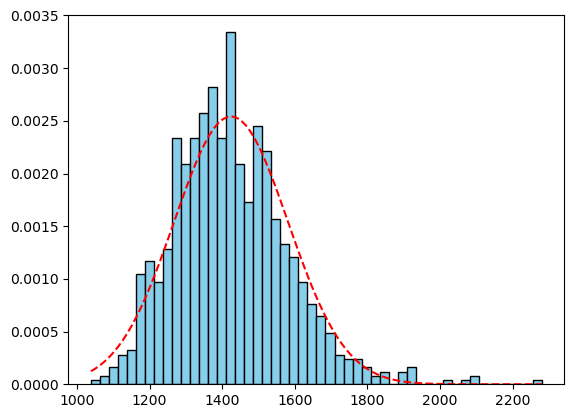

In [89]:

# TODO: Draw many samples and compute sample means
# sample_size = ...
# num_samples = ...
# sample_means = [np.mean(...your sampling code...) for _ in range(num_samples)]

# TODO: Plot the sampling distribution
# Number of samples

sample_size = 50
num_samples = 1000

sample_means = []

# Draw many samples and means
for i in range(num_samples):
    sample = np.random.choice(Pop, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))
    
mean, std = norm.fit(sample_means)
x = np.linspace(min(sample_means), max(sample_means), 100)

plt.hist(sample_means, bins=50, density=True, color='skyblue', edgecolor='black')

plt.plot(x, norm.pdf(x, loc=mean, scale=std), 'r--', label='Normal Approximation')


# Overlay a normal curve



## Summary

| Concept | Demonstrated With | Expected Observation |
|----------|------------------|----------------------|
| **LLN** | Increasing sample size | Sample mean approaches population mean |
| **CLT** | Repeated sampling | Sampling distribution becomes normal |
